# Análise Exploratória e Pré-Processamento de Dados
## Projeto Integrador 4 - Detecção de Fraude em Cartão de Crédito

Este notebook realiza a **Análise Exploratória de Dados (EDA)** e o **preparo** do conjunto de dados de transações financeiras (`creditcard.csv`, versionado comprimido em `dados/creditcard.csv.xz`).
Ele é a etapa 1 do projeto, cujo objetivo é **comparar três classificadores para detecção de fraude**: `SGDClassifier` (modelo linear), **LightGBM** (boosting de árvores) e uma **rede neural** (`MLPClassifier`).

### Objetivos deste Notebook:
1. **Inspeção Inicial**: Dimensões, tipos primitivos, valores ausentes e registros duplicados. As duplicatas exatas são **removidas antes da divisão treino/teste**.
2. **Diagnóstico do Desbalanceamento**: Proporção de transações legítimas vs. fraudulentas e a linha de base de um classificador trivial (por que a acurácia engana).
3. **Análise Temporal (`Time`)**: Conversão dos segundos em hora do dia, taxa de fraude por hora e por dia, e fraudes em rajadas.
4. **Análise de Valores Monetários (`Amount`)**: Comparação entre as classes, valores zero, taxa de fraude por faixa de valor e testes estatísticos.
5. **Componentes Principais (`V1` a `V28`)**: Forma das distribuições, poder discriminatório de cada atributo (Pearson, ROC-AUC, KS e informação mútua) e redundância entre eles.
6. **Outliers**: Diagnóstico com a regra do IQR e decisão sobre removê-los ou não.
7. **Partição Estratificada Salva em Arquivo**: Mesmas linhas de treino e teste para os três modelos.

**Cuidados contra vazamento de dados (*data leakage*)**: as duplicatas são removidas antes da divisão (senão cópias da mesma transação ficariam no treino e no teste); nenhuma transformação é ajustada aqui: o escalonamento fica para a etapa de modelagem, dentro do `Pipeline` de cada modelo, ajustado dentro de cada fold da validação cruzada; as estatísticas descritivas deste notebook não são usadas para selecionar atributos.

Os números citados como **"testes preliminares"** vêm de experimentos de modelagem feitos na revisão desta etapa, fora deste notebook; servem só para justificar as decisões de preparo e como referência para as próximas etapas.

In [1]:
# 1. Importação das bibliotecas essenciais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split

# Funções compartilhadas do projeto (pasta src/): todas as etapas preparam os dados da mesma forma
from src.preparo import (CAMINHO_SPLIT, COLUNAS_ATRIBUTOS, COLUNAS_ORIGINAIS, COLUNAS_V, RAIZ_PROJETO, SEED,
                         carregar_dados, carregar_particao, criar_atributos, dividir_treino_teste,
                         remover_duplicatas, salvar_split)

# Configurações visuais dos gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

# Cores e rótulos usados em todo o notebook
COR_LEGITIMA = '#2b5c8f'
COR_FRAUDE = '#d9534f'
PALETA_CLASSES = {0: COR_LEGITIMA, 1: COR_FRAUDE}
ROTULOS_CLASSES = ['Legítima (0)', 'Fraude (1)']

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# Funções auxiliares para as análises de taxa de fraude

def intervalo_wilson(fraudes, total, z=1.96):
    """Intervalo de confiança de 95% (método de Wilson) para a proporção fraudes / total.
    Funciona bem mesmo com proporções muito pequenas (como 0,17%) ou com zero fraudes."""
    fraudes = np.asarray(fraudes, dtype=float)
    total = np.asarray(total, dtype=float)
    p = fraudes / total
    centro = (p + z**2 / (2 * total)) / (1 + z**2 / total)
    margem = z * np.sqrt(p * (1 - p) / total + z**2 / (4 * total**2)) / (1 + z**2 / total)
    return np.clip(centro - margem, 0, 1), np.clip(centro + margem, 0, 1)


def taxa_de_fraude(dados, agrupador):
    """Transações, fraudes e taxa de fraude (%) com IC 95% para cada grupo.
    `agrupador` pode ser o nome de uma coluna ou uma série/array com um rótulo por transação."""
    tabela = dados.groupby(agrupador, observed=True)['Class'].agg(transacoes='count', fraudes='sum')
    tabela['taxa_%'] = 100 * tabela['fraudes'] / tabela['transacoes']
    inferior, superior = intervalo_wilson(tabela['fraudes'], tabela['transacoes'])
    tabela['IC95_inf_%'] = 100 * inferior
    tabela['IC95_sup_%'] = 100 * superior
    return tabela


def grafico_taxa(tabela, eixo, taxa_global, rotulos=None, posicao_legenda='upper right', folga=1.3):
    """Barras da taxa de fraude (%) com IC 95% e uma linha tracejada na taxa global."""
    posicoes = np.arange(len(tabela))
    topo_eixo = tabela['IC95_sup_%'].max() * folga   # espaço livre acima das barras para a legenda
    erro = np.array([tabela['taxa_%'] - tabela['IC95_inf_%'], tabela['IC95_sup_%'] - tabela['taxa_%']])
    eixo.bar(posicoes, tabela['taxa_%'], yerr=erro, color=COR_FRAUDE, alpha=0.85, capsize=3, ecolor='#444444')
    eixo.axhline(taxa_global, color='black', linestyle='--', linewidth=1, label=f'Taxa global ({taxa_global:.3f}%)')
    # Número de fraudes acima de cada barra: mostra quando a taxa se baseia em poucos casos
    for x, (fraudes, topo) in enumerate(zip(tabela['fraudes'], tabela['IC95_sup_%'])):
        eixo.text(x, topo + 0.01 * topo_eixo, f'{fraudes}', ha='center', va='bottom', fontsize=8, color='#444444',
                  bbox=dict(facecolor='white', edgecolor='none', pad=0.5, alpha=0.8))
    eixo.plot([], [], ' ', label='Número acima da barra = fraudes')
    eixo.set_xticks(posicoes, tabela.index if rotulos is None else rotulos)
    eixo.set_ylim(0, topo_eixo)
    eixo.set_ylabel('Taxa de fraude (%)')
    eixo.legend(loc=posicao_legenda, frameon=True)

## 1. Carregamento e Inspeção Inicial dos Dados

O carregamento usa `carregar_dados()` do módulo `src/preparo.py`, o mesmo usado pelos notebooks de modelagem.

In [3]:
# Carregamento do dataset (função do módulo compartilhado src/preparo.py)
dados_originais = carregar_dados()

print(f"Dimensões do conjunto de dados: {dados_originais.shape[0]:,} linhas e {dados_originais.shape[1]} colunas.\n")
dados_originais.head()

Dimensões do conjunto de dados: 284,807 linhas e 31 colunas.



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Verificação de tipos, valores ausentes e duplicatas
tipos_colunas = {str(tipo): quantidade for tipo, quantidade in dados_originais.dtypes.value_counts().items()}
total_nulos = dados_originais.isnull().sum().sum()
total_duplicatas = dados_originais.duplicated().sum()

print(f"Tipos das colunas: {tipos_colunas}")
print(f"Total de valores nulos no dataset: {total_nulos}")
print(f"Total de registros duplicados: {total_duplicatas:,} ({(total_duplicatas / len(dados_originais)) * 100:.2f}%)")

Tipos das colunas: {'float64': 30, 'int64': 1}
Total de valores nulos no dataset: 0
Total de registros duplicados: 1,081 (0.38%)


**O que observamos:** O arquivo tem 284.807 transações e 31 colunas, todas numéricas (30 `float64` e `Class` como `int64`), e nenhum valor ausente: não é preciso imputar nada. Há, porém, 1.081 linhas (0,38%) que são duplicatas exatas de outras, detalhadas a seguir.

In [5]:
# Detalhamento das duplicatas: quantas envolvem fraudes?
# keep=False marca TODAS as linhas que têm ao menos uma cópia idêntica (nas 31 colunas);
# keep='first' marca só as cópias extras, que seriam removidas
envolvidas = dados_originais.duplicated(keep=False)
copias_extras = dados_originais.duplicated(keep='first')

detalhe_duplicatas = pd.DataFrame({
    'Linhas com cópia idêntica': dados_originais[envolvidas].groupby('Class').size(),
    'Cópias extras (a remover)': dados_originais[copias_extras].groupby('Class').size(),
    'Total da classe': dados_originais.groupby('Class').size(),
})
# Cada grupo de k linhas iguais tem k - 1 cópias extras
detalhe_duplicatas['Grupos de duplicatas'] = (detalhe_duplicatas['Linhas com cópia idêntica']
                                              - detalhe_duplicatas['Cópias extras (a remover)'])
detalhe_duplicatas['% da classe que é cópia extra'] = (100 * detalhe_duplicatas['Cópias extras (a remover)']
                                                       / detalhe_duplicatas['Total da classe'])
detalhe_duplicatas.index = ROTULOS_CLASSES
display(detalhe_duplicatas.round(2))

# O que acontecia na divisão da versão anterior deste notebook (feita SEM remover as duplicatas)?
idx_treino_antigo, idx_teste_antigo = train_test_split(
    dados_originais.index, test_size=0.20, random_state=42, stratify=dados_originais['Class'])
# Um código (hash) por linha: linhas idênticas recebem o mesmo código
assinatura = pd.util.hash_pandas_object(dados_originais, index=False)
tem_gemeo_no_treino = assinatura.loc[idx_teste_antigo].isin(assinatura.loc[idx_treino_antigo].to_numpy())
fraude_no_teste_antigo = dados_originais.loc[idx_teste_antigo, 'Class'] == 1

print(f"Divisão antiga: {tem_gemeo_no_treino.sum():,} das {len(idx_teste_antigo):,} linhas do teste tinham cópia exata no treino,")
print(f"incluindo {(tem_gemeo_no_treino & fraude_no_teste_antigo).sum()} das {fraude_no_teste_antigo.sum()} fraudes do teste.")

,Linhas com cópia idêntica,Cópias extras (a remover),Total da classe,Grupos de duplicatas,% da classe que é cópia extra
Legítima (0),1822,1062,284315,760,0.37
Fraude (1),32,19,492,13,3.86


Divisão antiga: 344 das 56,962 linhas do teste tinham cópia exata no treino,
incluindo 8 das 98 fraudes do teste.


**O que observamos:** Das 1.081 cópias extras, 1.062 são legítimas e 19 são fraudes (773 grupos de linhas idênticas, 13 deles de fraude). Proporcionalmente, as fraudes se repetem cerca de 10 vezes mais: 3,86% das fraudes são cópias extras, contra 0,37% das legítimas. Na divisão da versão anterior deste notebook, 344 das 56.962 linhas do teste tinham uma cópia exata no treino, incluindo **8 das 98 fraudes do teste**.

In [6]:
# Remoção das duplicatas exatas ANTES de qualquer divisão treino/teste
# (mesma função usada nos notebooks de modelagem: uma única fonte de verdade)
dados, resumo_duplicatas = remover_duplicatas(dados_originais)
display(pd.Series(resumo_duplicatas, name='Quantidade').to_frame())

print(f"Proporção de fraudes: {dados_originais['Class'].mean() * 100:.3f}% (original) -> "
      f"{dados['Class'].mean() * 100:.3f}% (sem duplicatas)")

,Quantidade
linhas_antes,284807
linhas_depois,283726
duplicatas_removidas,1081
fraudes_antes,492
fraudes_depois,473
copias_de_fraude_removidas,19


Proporção de fraudes: 0.173% (original) -> 0.167% (sem duplicatas)


### Decisão: remover duplicatas

- **São cópias exatas**: as linhas repetidas são iguais nas 31 colunas, inclusive em `Time` (mesmo segundo) e `Amount`. Não há como saber se são transações reais repetidas ou erros de registro; tratá-las como uma única transação é a escolha conservadora.
- **Inflariam as métricas**: se uma cópia fica no treino e a outra no teste, o modelo é avaliado numa transação que já viu. Na divisão antiga isso acontecia com 8 das 98 fraudes do teste; nos testes preliminares da revisão, as cópias aumentaram a AP no teste em cerca de 0,01 a 0,03 (mais no SGD).
- **Remoção antes da divisão**: `remover_duplicatas()` mantém a primeira ocorrência de cada grupo e preserva o índice original. Restam **283.726 transações e 473 fraudes** (0,167% de fraudes, contra 0,173% no arquivo original). Toda a análise a seguir e a partição treino/teste usam esses dados.

## 2. Diagnóstico da Variável Alvo (`Class`) e Severidade do Desbalanceamento

A variável `Class` é o alvo da classificação:
- `0`: Transação Legítima
- `1`: Transação Fraudulenta

A partir daqui, toda a análise usa os dados **sem duplicatas** (`dados`).

,Quantidade,Proporção (%)
Legítima (0),283253,99.83329
Fraude (1),473,0.16671


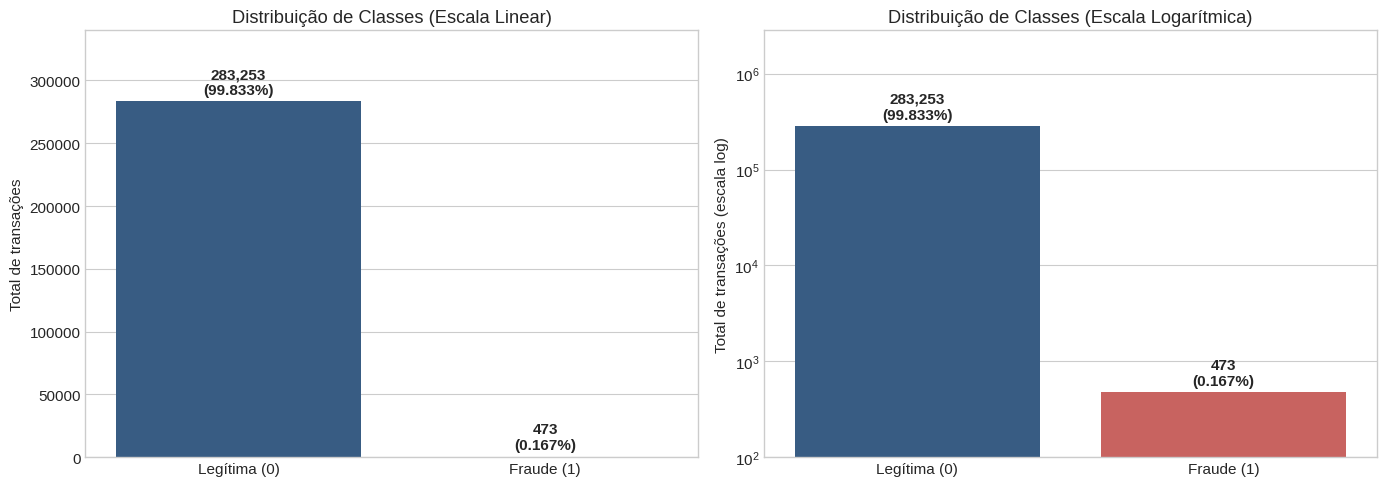

In [7]:
# Contagem absoluta e relativa das classes
contagem_classes = dados['Class'].value_counts().sort_index()
proporcao_classes = dados['Class'].value_counts(normalize=True).sort_index() * 100

tabela_distribuicao = pd.DataFrame({
    'Quantidade': contagem_classes,
    'Proporção (%)': proporcao_classes
})
tabela_distribuicao.index = ROTULOS_CLASSES
display(tabela_distribuicao)

# Visualização gráfica do desbalanceamento
fig, eixos = plt.subplots(1, 2, figsize=(14, 5))
textos_barras = [f"{valor:,}\n({proporcao:.3f}%)" for valor, proporcao in zip(contagem_classes.values, proporcao_classes.values)]

for eixo in eixos:
    # hue igual ao x e legend=False: forma atual do seaborn de dar uma cor a cada barra
    sns.barplot(x=ROTULOS_CLASSES, y=contagem_classes.values, hue=ROTULOS_CLASSES,
                palette=list(PALETA_CLASSES.values()), legend=False, ax=eixo)
    for barras, texto in zip(eixo.containers, textos_barras):
        eixo.bar_label(barras, labels=[texto], padding=3, fontweight='bold')
    eixo.set_xlabel('')

# Escala linear (folga no topo para o rótulo não encostar no título)
eixos[0].set_ylim(0, contagem_classes.max() * 1.2)
eixos[0].set_title('Distribuição de Classes (Escala Linear)')
eixos[0].set_ylabel('Total de transações')

# Escala logarítmica
eixos[1].set_yscale('log')
eixos[1].set_ylim(100, contagem_classes.max() * 10)
eixos[1].set_title('Distribuição de Classes (Escala Logarítmica)')
eixos[1].set_ylabel('Total de transações (escala log)')

plt.tight_layout()
plt.show()

**O que observamos:** Mesmo sem as duplicatas, o desbalanceamento é extremo: 283.253 legítimas para 473 fraudes, ou **0,167%** (cerca de 1 fraude a cada 600 transações). Na escala linear a barra das fraudes é praticamente invisível; só a escala log permite compará-las.

In [8]:
# Linha de base: um "classificador" que responde sempre "legítima"
alvo_y = dados['Class']
previsao_trivial = np.zeros(len(alvo_y), dtype=int)
acuracia_trivial = (previsao_trivial == alvo_y).mean()
recall_trivial = previsao_trivial[alvo_y == 1].mean()

# Para métricas de ranking, "sem informação" = o mesmo score para todas as transações
score_constante = np.zeros(len(alvo_y))
ap_trivial = average_precision_score(alvo_y, score_constante)
auc_trivial = roc_auc_score(alvo_y, score_constante)

print(f"Acurácia do classificador trivial:      {acuracia_trivial * 100:.3f}%")
print(f"Fraudes detectadas (recall):            {recall_trivial * 100:.1f}%")
print(f"Average Precision (AP) sem informação:  {ap_trivial:.5f}  (= proporção de fraudes: {alvo_y.mean():.5f})")
print(f"ROC-AUC sem informação:                 {auc_trivial:.2f}")

Acurácia do classificador trivial:      99.833%
Fraudes detectadas (recall):            0.0%
Average Precision (AP) sem informação:  0.00167  (= proporção de fraudes: 0.00167)
ROC-AUC sem informação:                 0.50


**O que observamos:** Um "classificador" que nunca aponta fraude tem **99,833% de acurácia** e não detecta nenhuma fraude (recall 0%): a acurácia é enganosa e não será usada para comparar modelos. A referência da métrica principal do projeto, a Average Precision (AP), é a própria proporção de fraudes (0,00167): um modelo útil precisa ficar muito acima disso. A ROC-AUC de um modelo sem informação é 0,5.

## 3. Análise da Variável Temporal (`Time`)

A variável `Time` armazena os segundos decorridos desde a primeira transação do arquivo (abrangendo um período de 48 horas / 2 dias).
Para extrair um padrão compreensível, convertemos os segundos em **hora do dia (ciclo de 0h a 23h)** com a função `criar_atributos()`: `Horas_Dia = (Time // 3600) % 24`.

**Suposição**: o dataset não informa o horário da primeira transação. Assumimos que `Time = 0` corresponde aproximadamente à **meia-noite**. A suposição é coerente com o volume de transações (gráfico (a) abaixo): há um vale entre 1h e 6h e o movimento cresce a partir das 7h, como se espera de compras com cartão. Se ela estiver errada, `Horas_Dia` continua representando o ciclo diário, só que com outra origem, e a leitura "madrugada" deixa de valer.

In [9]:
# Engenharia de atributos: hora do dia (0 a 23) derivada de Time (função de src/preparo.py)
dados = criar_atributos(dados)

# Dia da coleta (1 ou 2): usado só nesta análise, NÃO entra nos modelos
dados['Dia'] = (dados['Time'] // 86400).astype(int) + 1

print(f"Time vai de {dados['Time'].min():.0f} s a {dados['Time'].max():,.0f} s ({dados['Time'].max() / 3600:.2f} horas)")
print(f"Transações por dia: {dados['Dia'].value_counts().sort_index().to_dict()}")
dados[['Time', 'Horas_Dia', 'Dia', 'Class']].sample(5, random_state=SEED)

Time vai de 0 s a 172,792 s (48.00 horas)
Transações por dia: {1: 144236, 2: 139490}


,Time,Horas_Dia,Dia,Class
104697,69195.0,19,1,0
134356,80769.0,22,1,0
42637,41182.0,11,1,0
882,666.0,0,1,0
263275,160870.0,20,2,0


**O que observamos:** `Time` vai de 0 a 172.792 s (48 horas), com 144.236 transações no dia 1 e 139.490 no dia 2. `Horas_Dia` é um inteiro de 0 a 23 e entra nos modelos; `Dia` serve só para esta análise.

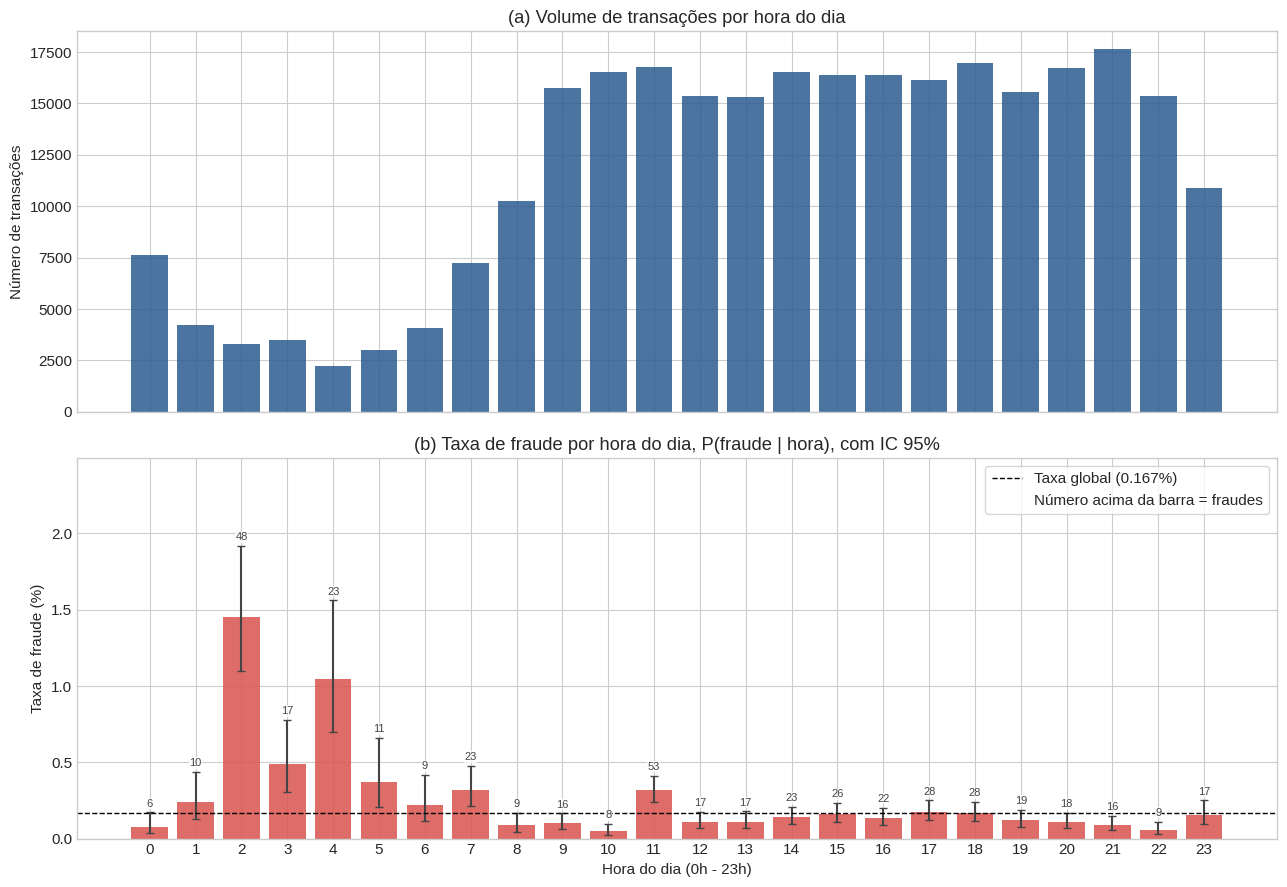

,transacoes,fraudes,taxa_%,IC95_inf_%,IC95_sup_%
Horas_Dia,,,,,
0,7647,6,0.078,0.036,0.171
1,4208,10,0.238,0.129,0.437
2,3308,48,1.451,1.096,1.918
3,3487,17,0.488,0.305,0.779
4,2204,23,1.044,0.696,1.561
5,2988,11,0.368,0.206,0.658
6,4082,9,0.220,0.116,0.419
7,7233,23,0.318,0.212,0.477
8,10232,9,0.088,0.046,0.167


In [10]:
# Volume de transações e taxa de fraude P(fraude | hora) em cada hora do dia (somando os 2 dias)
taxa_global = dados['Class'].mean() * 100
por_hora = taxa_de_fraude(dados, 'Horas_Dia')

fig, eixos = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# (a) Volume: quantas transações acontecem em cada hora
eixos[0].bar(por_hora.index, por_hora['transacoes'], color=COR_LEGITIMA, alpha=0.85)
eixos[0].set_title('(a) Volume de transações por hora do dia')
eixos[0].set_ylabel('Número de transações')

# (b) Taxa de fraude em cada hora, com IC 95% (Wilson) e a taxa global como referência
grafico_taxa(por_hora, eixos[1], taxa_global)
eixos[1].set_title('(b) Taxa de fraude por hora do dia, P(fraude | hora), com IC 95%')
eixos[1].set_xlabel('Hora do dia (0h - 23h)')

plt.tight_layout()
plt.show()

# Tabela completa: transações, fraudes e taxa de fraude (%) com IC 95% em cada hora
display(por_hora.round(3))

**O que observamos:** (a) O volume sustenta a suposição da meia-noite: cai de 7.647 transações às 0h para 2.204 às 4h e sobe a partir das 7h, ficando entre 15,3 mil e 17,6 mil por hora das 9h às 22h. (b) A taxa de fraude não acompanha o volume e não é monotônica: às **2h ela chega a 1,45%** (48 fraudes em 3.308 transações), quase 9 vezes a taxa global de 0,167%, e às 4h a 1,04%. Nas outras horas da madrugada a taxa também fica acima da global (0,49% às 3h, 0,37% às 5h, 0,24% à 1h e 0,22% às 6h; só a 0h fica abaixo, com 0,08%). Das 7h às 23h ela fica perto ou abaixo da taxa global, exceto pelos picos das 7h e das 11h (cerca de 0,32%). Os intervalos são largos na madrugada, que tem poucas transações.

In [11]:
# Resumo: madrugada (0h-6h) x demais horas
periodo = np.where(dados['Horas_Dia'] <= 6, 'Madrugada (0h-6h)', 'Demais horas (7h-23h)')
resumo_periodo = taxa_de_fraude(dados, periodo)
resumo_periodo['% das transações'] = 100 * resumo_periodo['transacoes'] / len(dados)
resumo_periodo['% das fraudes'] = 100 * resumo_periodo['fraudes'] / dados['Class'].sum()
display(resumo_periodo.round(3))

# Teste qui-quadrado de independência: a taxa de fraude é a mesma em todas as horas?
qui2_hora, p_hora, _, _ = stats.chi2_contingency(pd.crosstab(dados['Horas_Dia'], dados['Class']))
print(f"Qui-quadrado (hora x classe): qui2 = {qui2_hora:.1f}, p = {p_hora:.1e}")

,transacoes,fraudes,taxa_%,IC95_inf_%,IC95_sup_%,% das transações,% das fraudes
Demais horas (7h-23h),255802,349,0.136,0.123,0.152,90.158,73.784
Madrugada (0h-6h),27924,124,0.444,0.373,0.529,9.842,26.216


Qui-quadrado (hora x classe): qui2 = 548.2, p = 3.1e-101


**O que observamos:** A madrugada (0h-6h) concentra **26,2% das fraudes com apenas 9,8% das transações**: taxa de 0,444% contra 0,136% nas demais horas, cerca de 3 vezes maior. O teste qui-quadrado rejeita com folga que a taxa seja igual em todas as horas (p = 3,1e-101). Esse p é otimista, porque o teste supõe transações independentes e as fraudes chegam em rajadas (análise mais adiante); mas, mesmo contando cada rajada como um único evento, a madrugada continua com uma taxa cerca de 3 vezes maior. Um modelo linear só enxerga `Horas_Dia` como uma tendência (quanto mais cedo, mais fraude), enquanto árvores e redes neurais conseguem usar o pico das 2h. Nos testes preliminares, codificar a hora com seno/cosseno não mudou a AP, por isso `Horas_Dia` fica na forma simples.

,transacoes,fraudes,taxa_%,IC95_inf_%,IC95_sup_%
Dia,,,,,
1,144236,272,0.189,0.167,0.212
2,139490,201,0.144,0.126,0.165


Qui-quadrado (dia x classe): qui2 = 8.2, p = 0.0043


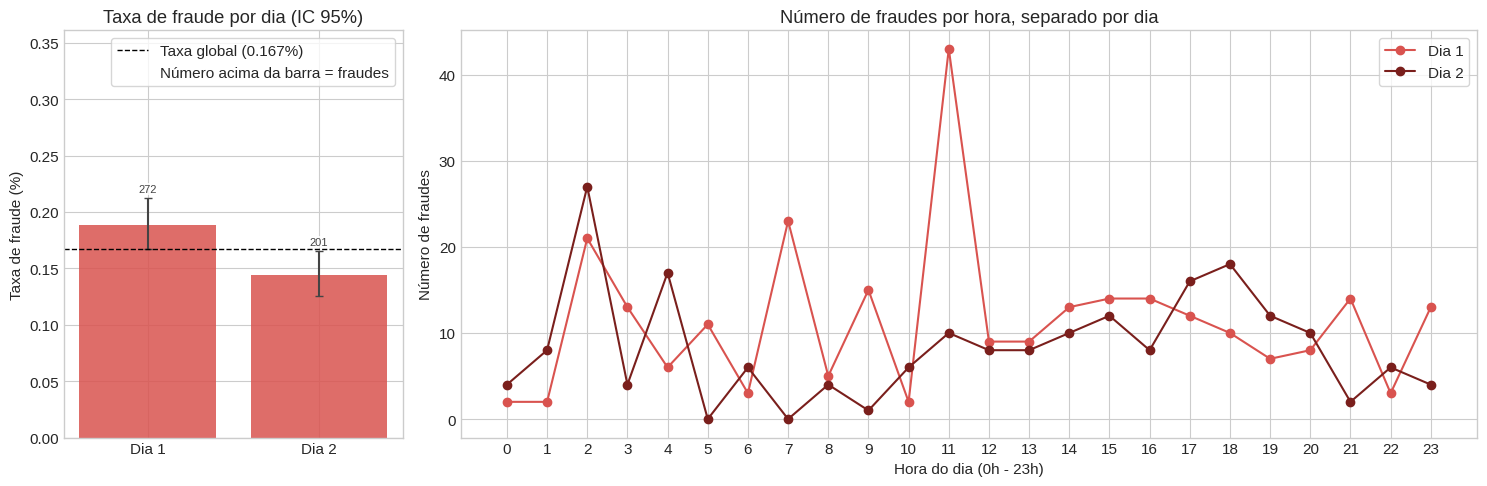

Dia,Dia 1,Dia 2
2h,21,27
4h,6,17
7h,23,0
11h,43,10


Sem as 7h e 11h: taxa de 0.156% no dia 1 e 0.150% no dia 2; qui2 = 0.1, p = 0.75


In [12]:
# Taxa de fraude em cada dia e número de fraudes por hora em cada dia
por_dia = taxa_de_fraude(dados, 'Dia')
display(por_dia.round(3))
qui2_dia, p_dia, _, _ = stats.chi2_contingency(pd.crosstab(dados['Dia'], dados['Class']))
print(f"Qui-quadrado (dia x classe): qui2 = {qui2_dia:.1f}, p = {p_dia:.4f}")

fraudes = dados[dados['Class'] == 1]
fraudes_hora_dia = pd.crosstab(fraudes['Horas_Dia'], fraudes['Dia']).reindex(range(24), fill_value=0)

fig, eixos = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1, 3]})

grafico_taxa(por_dia, eixos[0], taxa_global, rotulos=['Dia 1', 'Dia 2'], folga=1.7)
eixos[0].set_title('Taxa de fraude por dia (IC 95%)')

for dia, cor in [(1, COR_FRAUDE), (2, '#7a1f1c')]:
    eixos[1].plot(fraudes_hora_dia.index, fraudes_hora_dia[dia], marker='o', color=cor, label=f'Dia {dia}')
eixos[1].set_title('Número de fraudes por hora, separado por dia')
eixos[1].set_xticks(range(24))
eixos[1].set_xlabel('Hora do dia (0h - 23h)')
eixos[1].set_ylabel('Número de fraudes')
eixos[1].legend(frameon=True)

plt.tight_layout()
plt.show()

# Os picos de fraude acontecem nos dois dias ou num dia só?
picos = fraudes_hora_dia.loc[[2, 4, 7, 11]].rename(columns={1: 'Dia 1', 2: 'Dia 2'})
picos.index = [f'{hora}h' for hora in picos.index]
display(picos)

# Sem os picos das 7h e 11h (quase só do dia 1), a diferença entre os dias continua?
sem_picos = ~dados['Horas_Dia'].isin([7, 11])
por_dia_sem_picos = taxa_de_fraude(dados[sem_picos], 'Dia')
qui2_sem_picos, p_sem_picos, _, _ = stats.chi2_contingency(
    pd.crosstab(dados.loc[sem_picos, 'Dia'], dados.loc[sem_picos, 'Class']))
print(f"Sem as 7h e 11h: taxa de {por_dia_sem_picos.loc[1, 'taxa_%']:.3f}% no dia 1 e "
      f"{por_dia_sem_picos.loc[2, 'taxa_%']:.3f}% no dia 2; qui2 = {qui2_sem_picos:.1f}, p = {p_sem_picos:.2f}")

**O que observamos:** A taxa de fraude foi de 0,189% no dia 1 e 0,144% no dia 2. O qui-quadrado dá p = 0,0043, mas ele supõe transações independentes, e a análise a seguir mostra que as fraudes chegam em rajadas. O gráfico da direita mostra de onde vem a diferença: dos picos das 11h (43 fraudes no dia 1 contra 10 no dia 2) e das 7h (23 contra 0), praticamente eventos de um único dia, provavelmente ataques pontuais. Sem essas duas horas, as taxas ficam em 0,156% e 0,150% (p = 0,75). Ou seja, **não há evidência de que a prevalência de base mude entre os dias** (a contagem por rajadas, mais adiante, chega à mesma conclusão); o que muda é a ocorrência de ataques pontuais. Já o pico das 2h aparece nos dois dias (21 e 27 fraudes). Com apenas dois dias de dados, padrões de uma hora específica devem ser lidos com cautela.

,Fraudes reais (%),Ao acaso - média (%),Ao acaso - maior valor (%)
Outra fraude a até 10 s,22.4,7.1,11.8
Outra fraude a até 60 s,52.0,33.6,44.2
Outra fraude a até 300 s,86.9,84.0,88.8


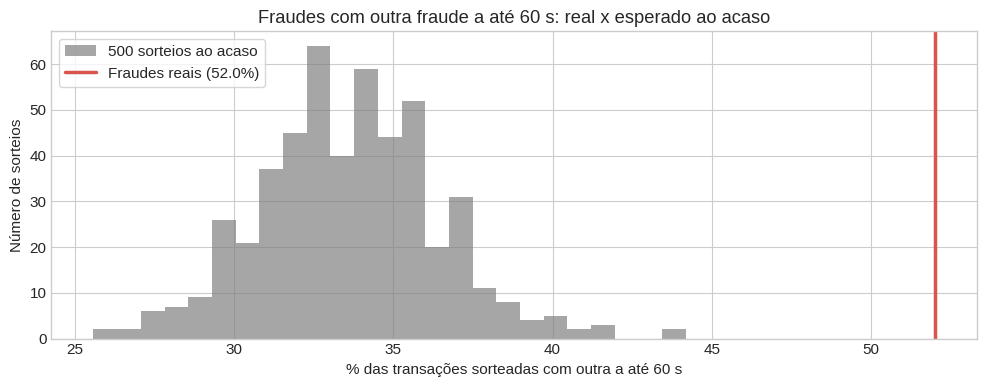

In [13]:
# Rajadas de fraudes: quantas fraudes têm OUTRA fraude a até `janela` segundos de distância?
def fracao_com_vizinho(tempos, janela):
    tempos = np.sort(tempos)
    perto = np.diff(tempos) <= janela
    tem_vizinho = np.zeros(len(tempos), dtype=bool)
    tem_vizinho[1:] |= perto    # vizinho anterior
    tem_vizinho[:-1] |= perto   # vizinho seguinte
    return tem_vizinho.mean()

janelas = [10, 60, 300]
tempos_fraudes = dados.loc[dados['Class'] == 1, 'Time'].to_numpy()
todos_tempos = dados['Time'].to_numpy()

# Referência "ao acaso": sorteamos o mesmo número de transações quaisquer (ignorando a classe)
# e medimos a mesma fração. O sorteio já leva em conta que há mais transações em certas horas.
gerador = np.random.default_rng(SEED)
n_sorteios = 500
simulado = {janela: [] for janela in janelas}
for _ in range(n_sorteios):
    amostra = gerador.choice(todos_tempos, size=len(tempos_fraudes), replace=False)
    for janela in janelas:
        simulado[janela].append(fracao_com_vizinho(amostra, janela))

tabela_rajadas = pd.DataFrame({
    'Fraudes reais (%)': [100 * fracao_com_vizinho(tempos_fraudes, janela) for janela in janelas],
    'Ao acaso - média (%)': [100 * np.mean(simulado[janela]) for janela in janelas],
    'Ao acaso - maior valor (%)': [100 * np.max(simulado[janela]) for janela in janelas],
}, index=[f'Outra fraude a até {janela} s' for janela in janelas])
display(tabela_rajadas.round(1))

# Visualização para a janela de 60 s
observado_60 = 100 * fracao_com_vizinho(tempos_fraudes, 60)
plt.figure(figsize=(10, 4))
plt.hist(100 * np.array(simulado[60]), bins=25, color='gray', alpha=0.7, label=f'{n_sorteios} sorteios ao acaso')
plt.axvline(observado_60, color=COR_FRAUDE, linewidth=2.5, label=f'Fraudes reais ({observado_60:.1f}%)')
plt.title('Fraudes com outra fraude a até 60 s: real x esperado ao acaso')
plt.xlabel('% das transações sorteadas com outra a até 60 s')
plt.ylabel('Número de sorteios')
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

**O que observamos:** As fraudes chegam em **rajadas**: 52,0% delas têm outra fraude a até 60 s, contra 33,6% esperados se os horários fossem sorteados ao acaso entre todas as transações, e nenhum dos 500 sorteios passou de 44,2%. Na janela de 10 s o contraste é maior (22,4% contra 7,1%); em 300 s a diferença some (86,9% contra 84,0%). **Consequência**: a divisão aleatória coloca fraudes da mesma rajada (provavelmente do mesmo ataque) no treino e no teste, o que tende a deixar a avaliação otimista. Por isso recomendamos, na etapa de modelagem, repetir a avaliação com uma **partição temporal** (treino com os primeiros 80% das transações em ordem de tempo, teste com os 20% finais) como verificação de robustez; a função `particao_temporal()` de `src/preparo.py` já faz essa divisão. A seguir, verificamos se as conclusões sobre a hora e o dia se mantêm quando cada rajada conta como um único evento.

In [14]:
# Contagem por rajada: fraudes a até 60 s umas das outras contam como um único evento (um provável ataque)
fraudes_no_tempo = dados[dados['Class'] == 1].sort_values('Time')
nova_rajada = fraudes_no_tempo['Time'].diff() > 60   # True quando a fraude está a mais de 60 s da anterior
numero_rajada = nova_rajada.cumsum()                 # número da rajada de cada fraude (a primeira é a rajada 0)
# Dia e hora de cada rajada = dia e hora da sua primeira fraude
rajadas = fraudes_no_tempo.groupby(numero_rajada).agg(fraudes=('Class', 'size'), dia=('Dia', 'first'),
                                                      hora=('Horas_Dia', 'first'))
maior_rajada = rajadas.loc[rajadas['fraudes'].idxmax()]
print(f"{len(fraudes_no_tempo)} fraudes formam {len(rajadas)} rajadas; a maior tem {maior_rajada['fraudes']} fraudes "
      f"(dia {maior_rajada['dia']}, {maior_rajada['hora']}h)")


def rajadas_por_grupo(grupo_rajadas, grupo_transacoes):
    """Rajadas por mil transações em cada grupo e qui-quadrado (rajadas x demais transações)."""
    tabela = pd.DataFrame({'transacoes': pd.Series(grupo_transacoes).value_counts(),
                           'rajadas': pd.Series(grupo_rajadas).value_counts()}).sort_index()
    tabela['rajadas_por_mil_transacoes'] = 1000 * tabela['rajadas'] / tabela['transacoes']
    _, p, _, _ = stats.chi2_contingency(np.column_stack([tabela['rajadas'], tabela['transacoes'] - tabela['rajadas']]))
    return tabela, p


# (a) Por dia
rajadas_dia, p_rajadas_dia = rajadas_por_grupo(rajadas['dia'], dados['Dia'])
rajadas_dia.index = ['Dia 1', 'Dia 2']
display(rajadas_dia.round(3))
print(f"Qui-quadrado (rajadas por dia): p = {p_rajadas_dia:.3f}")

# (b) Madrugada x demais horas (mesma divisão da tabela de períodos acima)
periodo_rajada = np.where(rajadas['hora'] <= 6, 'Madrugada (0h-6h)', 'Demais horas (7h-23h)')
rajadas_periodo, p_rajadas_periodo = rajadas_por_grupo(periodo_rajada, periodo)
display(rajadas_periodo.round(3))
print(f"Qui-quadrado (rajadas por período): p = {p_rajadas_periodo:.1e}")

473 fraudes formam 308 rajadas; a maior tem 21 fraudes (dia 1, 11h)


,transacoes,rajadas,rajadas_por_mil_transacoes
Dia 1,144236,172,1.192
Dia 2,139490,136,0.975


Qui-quadrado (rajadas por dia): p = 0.089


,transacoes,rajadas,rajadas_por_mil_transacoes
Demais horas (7h-23h),255802,229,0.895
Madrugada (0h-6h),27924,79,2.829


Qui-quadrado (rajadas por período): p = 2.9e-20


**O que observamos:** As 473 fraudes formam 308 rajadas; a maior tem 21 fraudes, às 11h do dia 1 (parte do pico visto na análise por dia). Contando cada rajada como um único evento, **a diferença entre os dias deixa de ser significativa**: 1,192 rajada por mil transações no dia 1 contra 0,975 no dia 2 (p = 0,089). Já a **madrugada mantém uma taxa cerca de 3 vezes maior** que a das demais horas: 2,829 contra 0,895 rajada por mil transações (p = 2,9e-20). Ou seja, o efeito da hora do dia não vem de contar várias vezes o mesmo ataque, enquanto a diferença entre os dias vem de poucos ataques concentrados.

## 4. Análise da Variável Monetária (`Amount`)

Análise da distribuição estatística dos valores financeiros movimentados em transações legítimas versus fraudulentas.

In [15]:
# Estatísticas descritivas comparativas de Amount
estatisticas_legitimas = dados[dados['Class'] == 0]['Amount'].describe()
estatisticas_fraudes = dados[dados['Class'] == 1]['Amount'].describe()

comparativo_valores = pd.DataFrame({
    'Legítimas (0)': estatisticas_legitimas,
    'Fraudes (1)': estatisticas_fraudes
})
display(comparativo_valores.round(2))

# Transações de valor zero ou muito baixo (as de valor zero somem num gráfico em escala log, pois log(0) não existe)
valor_zero = dados['Amount'] == 0
ate_um = dados['Amount'] <= 1
valores_baixos = pd.DataFrame({
    'Amount = 0': dados[valor_zero].groupby('Class').size(),
    '% da classe (= 0)': 100 * valor_zero.groupby(dados['Class']).mean(),
    'Amount <= 1': dados[ate_um].groupby('Class').size(),
    '% da classe (<= 1)': 100 * ate_um.groupby(dados['Class']).mean(),
})
valores_baixos.index = ROTULOS_CLASSES
display(valores_baixos.round(2))

,Legítimas (0),Fraudes (1)
count,283253.00,473.00
mean,88.41,123.87
std,250.38,260.21
min,0.00,0.00
25%,5.67,1.00
50%,22.00,9.82
75%,77.46,105.89
max,25691.16,2125.87


,Amount = 0,% da classe (= 0),Amount <= 1,% da classe (<= 1)
Legítima (0),1783,0.63,30160,10.65
Fraude (1),25,5.29,171,36.15


**O que observamos:** A média das fraudes (US$ 123,87) é maior que a das legítimas (US$ 88,41), mas a mediana é menor (US$ 9,82 contra US$ 22,00): as fraudes se concentram em valores muito baixos e em alguns valores altos. **5,29% das fraudes têm valor zero**, contra 0,63% das legítimas, e 36,15% têm valor de até US$ 1 (10,65% nas legítimas). O maior valor fraudado é US$ 2.125,87, enquanto há legítimas de até US$ 25.691,16.

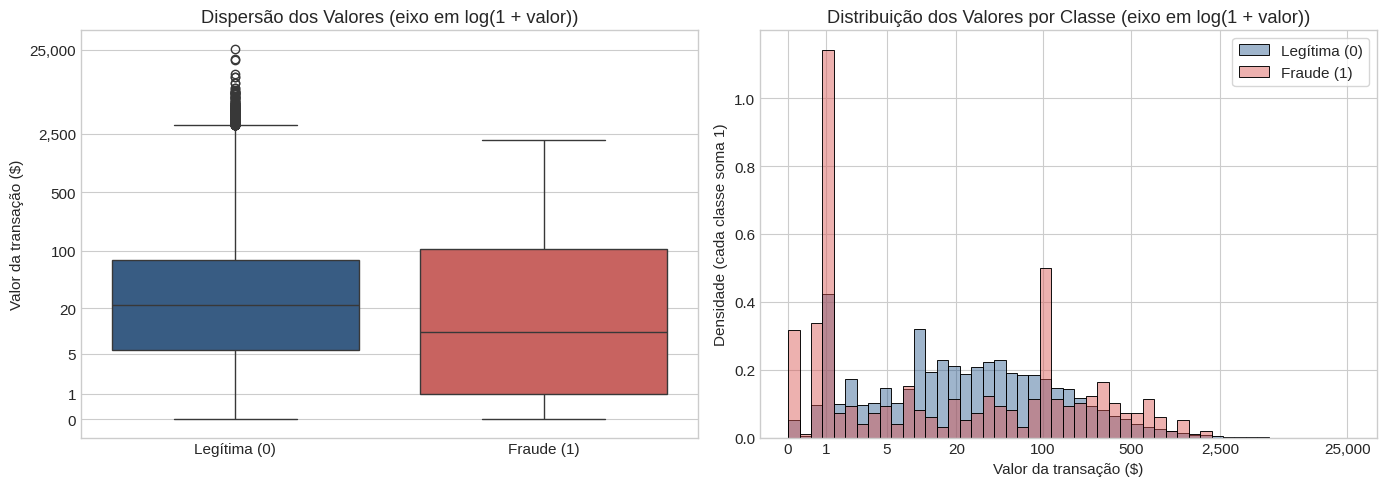

,fraudes
Amount,
1.00,105
99.99,27
0.00,25
0.76,17
0.77,10


In [16]:
# log1p(x) = log(1 + x): comprime a cauda longa e, ao contrário do log, aceita o valor zero
dados_grafico = dados[['Amount', 'Class']].assign(Amount_log1p=np.log1p(dados['Amount']))
marcas_valor = [0, 1, 5, 20, 100, 500, 2500, 25000]
posicoes_marcas = np.log1p(marcas_valor)
rotulos_marcas = [f'{valor:,}' for valor in marcas_valor]

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot no eixo log(1 + valor), com os rótulos em dólares
sns.boxplot(data=dados_grafico, x='Class', y='Amount_log1p', hue='Class', palette=PALETA_CLASSES,
            legend=False, ax=eixos[0])
eixos[0].set_xticks([0, 1], ROTULOS_CLASSES)
eixos[0].set_yticks(posicoes_marcas, rotulos_marcas)
eixos[0].set_title('Dispersão dos Valores (eixo em log(1 + valor))')
eixos[0].set_xlabel('')
eixos[0].set_ylabel('Valor da transação ($)')

# Histograma normalizado por classe (área 1 em cada classe) para comparar as formas apesar do desbalanceamento
limites_bins = np.linspace(0, dados_grafico['Amount_log1p'].max(), 50)
for classe, rotulo in zip([0, 1], ROTULOS_CLASSES):
    sns.histplot(dados_grafico.loc[dados_grafico['Class'] == classe, 'Amount_log1p'], bins=limites_bins,
                 stat='density', color=PALETA_CLASSES[classe], alpha=0.45, label=rotulo, ax=eixos[1])
eixos[1].set_xticks(posicoes_marcas, rotulos_marcas)
eixos[1].set_title('Distribuição dos Valores por Classe (eixo em log(1 + valor))')
eixos[1].set_xlabel('Valor da transação ($)')
eixos[1].set_ylabel('Densidade (cada classe soma 1)')
eixos[1].legend(frameon=True)

plt.tight_layout()
plt.show()

# Valores mais frequentes entre as fraudes (os picos do histograma)
display(dados.loc[dados['Class'] == 1, 'Amount'].value_counts().head(5).rename('fraudes').to_frame())

**O que observamos:** Com o eixo em log(1 + valor), as transações de valor zero aparecem (no gráfico em escala log da versão anterior elas sumiam, pois log(0) não existe). O boxplot mostra que metade das fraudes está abaixo de US$ 9,82 e o histograma mostra os picos das fraudes em US$ 0-1 (US$ 1,00 é o valor mais comum, com 105 fraudes) e perto de US$ 100 (99,99 aparece em 27 fraudes). As legítimas se espalham de forma mais contínua entre US$ 5 e US$ 500.

,transacoes,fraudes,taxa_%,IC95_inf_%,IC95_sup_%
Amount,,,,,
0,1808,25,1.383,0.938,2.033
0-1,28523,146,0.512,0.435,0.602
1-5,38416,40,0.104,0.076,0.142
5-10,31074,27,0.087,0.060,0.126
10-25,49819,27,0.054,0.037,0.079
25-50,40508,28,0.069,0.048,0.100
50-100,37179,55,0.148,0.114,0.192
100-250,33828,54,0.160,0.122,0.208
250-500,13462,37,0.275,0.199,0.379


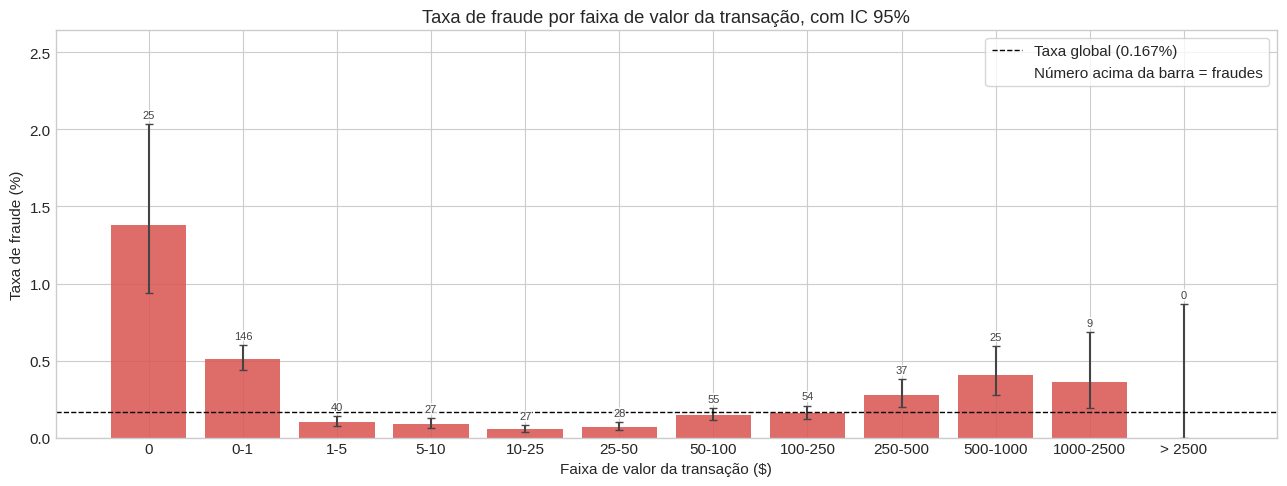

In [17]:
# Taxa de fraude por faixa de valor: intervalos (a, b], com uma faixa só para o valor zero
limites_faixas = [-0.01, 0, 1, 5, 10, 25, 50, 100, 250, 500, 1000, 2500, np.inf]
nomes_faixas = ['0', '0-1', '1-5', '5-10', '10-25', '25-50', '50-100', '100-250',
                '250-500', '500-1000', '1000-2500', '> 2500']
faixa_valor = pd.cut(dados['Amount'], bins=limites_faixas, labels=nomes_faixas)
por_faixa = taxa_de_fraude(dados, faixa_valor)
display(por_faixa.round(3))

fig, eixo = plt.subplots(figsize=(13, 5))
grafico_taxa(por_faixa, eixo, taxa_global)
eixo.set_title('Taxa de fraude por faixa de valor da transação, com IC 95%')
eixo.set_xlabel('Faixa de valor da transação ($)')
plt.tight_layout()
plt.show()

**O que observamos:** A taxa de fraude por faixa de valor tem **forma de U**: é máxima no valor zero (1,38%, cerca de 8 vezes a taxa global) e em US$ 0-1 (0,51%), cai ao mínimo entre US$ 10 e 25 (0,054%) e volta a subir acima de US$ 250 (0,40% entre US$ 500 e 1.000). Acima de US$ 2.500 não há nenhuma fraude em 440 transações. Por não ser monotônica, essa relação é aproveitada naturalmente por árvores; um modelo linear enxerga só uma tendência.

In [18]:
# Testes não paramétricos: os valores das fraudes seguem a mesma distribuição dos valores das legítimas?
valores_fraude = dados.loc[dados['Class'] == 1, 'Amount']
valores_legitima = dados.loc[dados['Class'] == 0, 'Amount']

mann_whitney = stats.mannwhitneyu(valores_fraude, valores_legitima, alternative='two-sided')
teste_ks = stats.ks_2samp(valores_fraude, valores_legitima)
# Tamanho do efeito: U / (n_fraudes * n_legitimas) é a ROC-AUC do próprio Amount usado como score
auc_amount = mann_whitney.statistic / (len(valores_fraude) * len(valores_legitima))

print(f"Mann-Whitney U:      p = {mann_whitney.pvalue:.1e} | AUC de Amount = {auc_amount:.3f}")
print(f"Kolmogorov-Smirnov:  D = {teste_ks.statistic:.3f}, p = {teste_ks.pvalue:.1e}")

Mann-Whitney U:      p = 2.7e-05 | AUC de Amount = 0.444
Kolmogorov-Smirnov:  D = 0.265, p = 7.4e-30


**O que observamos:** Os dois testes rejeitam que as distribuições sejam iguais (Mann-Whitney p = 2,7e-05; KS D = 0,265, p = 7,4e-30). Mas, com 283 mil transações, até diferenças pequenas ficam "significativas", e o tamanho do efeito importa mais. A AUC de `Amount` sozinho é 0,444 (0,556 no sentido inverso): como separador **monotônico** ("quanto menor o valor, mais fraude"), ele é fraco. A AUC, porém, só mede esse tipo de separação. As fraudes têm, ao mesmo tempo, mais valores muito baixos (mediana de US$ 9,82 contra US$ 22,00) e mais valores altos (3º quartil de US$ 105,89 contra US$ 77,46); o KS (D = 0,265), que compara as distribuições inteiras, e a forma de U da seção anterior mostram que a relação existe, mas muda de sentido conforme a faixa de valor. `Amount` entra nos modelos como complemento: as árvores e a MLP podem aproveitar essa forma de U, e o SGD enxerga só uma tendência.

## 5. Análise das Componentes Principais (`V1` a `V28`)

As variáveis `V1` a `V28` são componentes principais derivadas via PCA para resguardar a privacidade dos clientes.
Vamos analisar a forma das suas distribuições, o poder de cada atributo para separar fraudes de legítimas e a redundância entre eles.

**Nota sobre vazamento**: as estatísticas desta seção usam todos os dados (sem duplicatas), inclusive as linhas que serão o teste. Isso é aceitável porque elas são **apenas descritivas**: nenhuma é usada para escolher atributos. Os **30 atributos** (`V1`-`V28`, `Amount`, `Horas_Dia`) vão todos para os modelos.

In [19]:
# Forma das distribuições: escala (desvio-padrão), assimetria e peso das caudas (curtose)
# Curtose em excesso (padrão do pandas): 0 = distribuição normal; valores altos = caudas pesadas
colunas_forma = COLUNAS_V + ['Amount']
forma = pd.DataFrame({
    'média': dados[colunas_forma].mean(),
    'desvio_padrão': dados[colunas_forma].std(),
    'mínimo': dados[colunas_forma].min(),
    'máximo': dados[colunas_forma].max(),
    'assimetria': dados[colunas_forma].skew(),
    'curtose_excesso': dados[colunas_forma].kurt(),
})
display(forma.round(2))

forma_v = forma.loc[COLUNAS_V]
print(f"V1-V28: desvio-padrão de {forma_v['desvio_padrão'].min():.2f} a {forma_v['desvio_padrão'].max():.2f}; "
      f"maior |valor| = {dados[COLUNAS_V].abs().max().max():.1f}; curtose em excesso de {forma_v['curtose_excesso'].min():.1f} a {forma_v['curtose_excesso'].max():.1f}")

,média,desvio_padrão,mínimo,máximo,assimetria,curtose_excesso
V1,0.01,1.95,-56.41,2.45,-3.27,32.73
V2,-0.00,1.65,-72.72,22.06,-4.70,96.90
V3,0.00,1.51,-48.33,9.38,-2.15,25.19
V4,-0.00,1.41,-5.68,16.88,0.67,2.62
V5,0.00,1.38,-113.74,34.80,-2.41,209.28
V6,-0.00,1.33,-26.16,73.30,1.83,42.84
V7,0.00,1.23,-43.56,120.59,2.89,414.14
V8,-0.00,1.18,-73.22,20.01,-8.31,215.02
V9,-0.00,1.10,-13.43,15.59,0.54,3.52
V10,-0.00,1.08,-24.59,23.75,1.25,29.84


V1-V28: desvio-padrão de 0.33 a 1.95; maior |valor| = 120.6; curtose em excesso de 0.2 a 959.4


**O que observamos:** As V's têm média próxima de 0 (são componentes PCA centradas), mas escalas diferentes: o desvio-padrão vai de 0,33 (V28) a 1,95 (V1). As caudas são pesadas, com valores de até 120,6 em módulo e curtose em excesso (0 numa distribuição normal) de até 959 (V28); `Amount` tem desvio-padrão de 250 e assimetria de 17. Por isso o SGD e a MLP, sensíveis à escala, recebem um `StandardScaler` dentro do seu `Pipeline` (ajustado só no treino de cada fold), e o LightGBM não precisa dele. Nos testes preliminares, escalonar todos os atributos ou aplicar log1p em `Amount` não mudou a AP de forma mensurável: o escalonamento é boa prática, não ganho de desempenho.

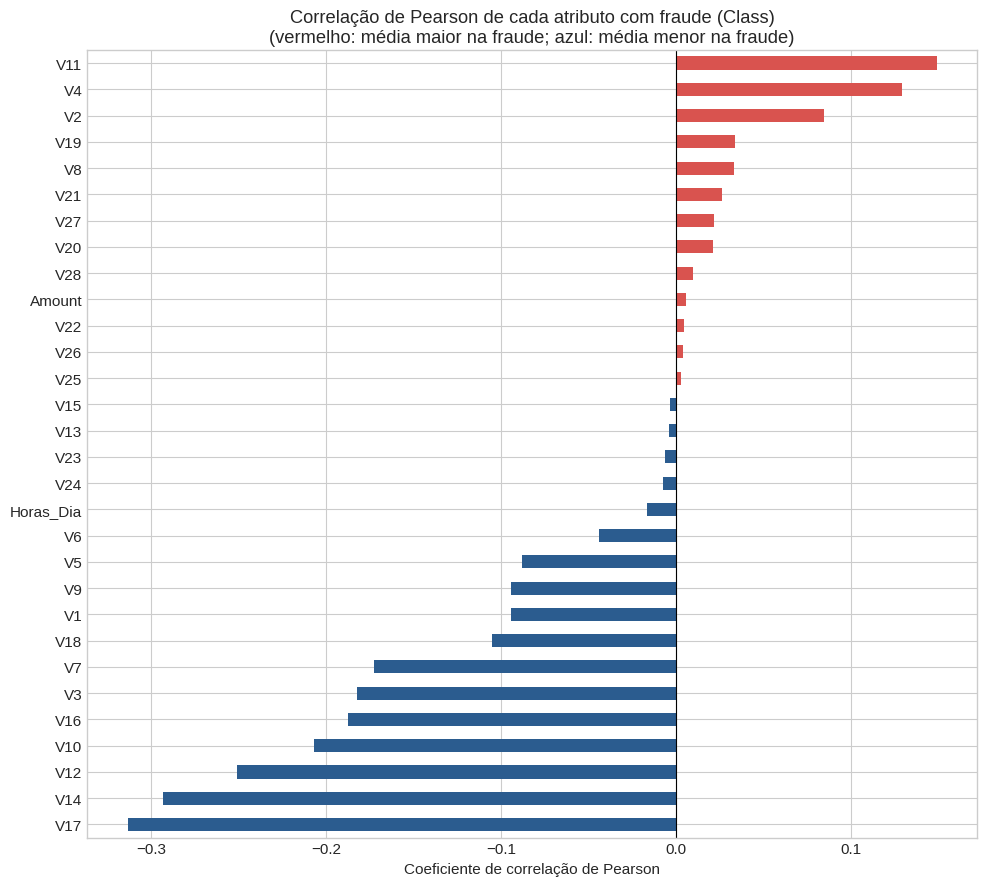

In [20]:
# Correlação de Pearson de cada um dos 30 atributos com 'Class'
correlacoes = dados[COLUNAS_ATRIBUTOS].corrwith(dados['Class']).sort_values()
# Com um alvo binário, r > 0 quer dizer que a MÉDIA do atributo é maior nas fraudes

plt.figure(figsize=(10, 9))
cores_grafico = [COR_FRAUDE if valor > 0 else COR_LEGITIMA for valor in correlacoes.values]
correlacoes.plot(kind='barh', color=cores_grafico)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlação de Pearson de cada atributo com fraude (Class)\n(vermelho: média maior na fraude; azul: média menor na fraude)')
plt.xlabel('Coeficiente de correlação de Pearson')
plt.tight_layout()
plt.show()

**O que observamos:** As maiores correlações em módulo são V17 (-0,31), V14 (-0,29) e V12 (-0,25), e as positivas mais fortes são V11 (+0,15) e V4 (+0,13). Nenhuma passa de 0,32: com uma classe de 0,17%, a correlação de Pearson com um alvo binário fica "comprimida" e subestima atributos que separam bem as classes. `Amount` (+0,006) e `Horas_Dia` (-0,017) quase não têm correlação linear, embora tenham relação não linear com a fraude (seções 3 e 4).

In [21]:
# Poder discriminatório de cada atributo SOZINHO, por quatro medidas complementares:
# - |r| de Pearson: relação linear; com 0,17% de fraudes ela fica "comprimida" (baixa até para bons atributos)
# - ROC-AUC do atributo usado como score: 0,5 = sem poder; mostramos max(AUC, 1 - AUC) e a direção
#   (direção pela AUC: se os valores das fraudes TENDEM a ser maiores ou menores que os das legítimas)
# - KS: maior distância entre as distribuições acumuladas das duas classes (0 a 1)
# - Informação mútua: mede dependência de qualquer forma, não só monotônica (cálculo leva cerca de 30 s)
eh_fraude = dados['Class'] == 1
linhas = []
for atributo in COLUNAS_ATRIBUTOS:
    auc = roc_auc_score(dados['Class'], dados[atributo])
    ks = stats.ks_2samp(dados.loc[eh_fraude, atributo], dados.loc[~eh_fraude, atributo]).statistic
    linhas.append({'atributo': atributo,
                   'r_pearson': correlacoes[atributo],
                   'abs_r': abs(correlacoes[atributo]),
                   'AUC': max(auc, 1 - auc),
                   'direcao': 'maior na fraude' if auc > 0.5 else 'menor na fraude',
                   'KS': ks})
ranking = pd.DataFrame(linhas).set_index('atributo')

ranking['info_mutua'] = mutual_info_classif(dados[COLUNAS_ATRIBUTOS], dados['Class'],
                                            discrete_features=[coluna == 'Horas_Dia' for coluna in COLUNAS_ATRIBUTOS],
                                            random_state=SEED)

# Posição de cada atributo em cada medida (1 = melhor)
for medida, nome in [('abs_r', 'pos_r'), ('AUC', 'pos_AUC'), ('KS', 'pos_KS'), ('info_mutua', 'pos_MI')]:
    ranking[nome] = ranking[medida].rank(ascending=False).astype(int)

ranking = ranking.sort_values('AUC', ascending=False)
display(ranking[['r_pearson', 'pos_r', 'AUC', 'direcao', 'pos_AUC', 'KS', 'pos_KS', 'info_mutua', 'pos_MI']].round(4))

,r_pearson,pos_r,AUC,direcao,pos_AUC,KS,pos_KS,info_mutua,pos_MI
atributo,,,,,,,,,
V14,-0.2934,2,0.9471,menor na fraude,1,0.8377,1,0.0077,2
V4,0.1293,9,0.9363,maior na fraude,2,0.7607,4,0.0046,7
V12,-0.2507,3,0.9345,menor na fraude,3,0.7766,3,0.0072,3
V11,0.1491,8,0.9148,maior na fraude,4,0.7474,5,0.0064,5
V10,-0.2070,4,0.9106,menor na fraude,5,0.7970,2,0.0072,4
V3,-0.1823,6,0.9086,menor na fraude,6,0.6952,7,0.0046,8
V2,0.0846,14,0.8498,maior na fraude,7,0.6241,10,0.0029,12
V16,-0.1872,5,0.8414,menor na fraude,8,0.6782,8,0.0058,6
V9,-0.0940,12,0.8413,menor na fraude,9,0.5752,11,0.0039,10


**O que observamos:** Pela ROC-AUC univariada, os melhores atributos são **V14 (0,947), V4 (0,936), V12 (0,934) e V11 (0,915)**, seguidos de V10 (0,911) e V3 (0,909); 11 atributos têm AUC acima de 0,8. As medidas discordam em alguns casos: V17 é o 1º por |r| e por informação mútua, mas só o 11º por AUC (0,800), e V4 é o 9º por |r| mas o 2º por AUC. O KS concorda com a AUC em 3 dos 4 primeiros (V14, V12 e V4); no lugar de V11 (5º pelo KS) entra V10 (5º pela AUC e 2º pelo KS). `Amount` aparece com sentidos opostos nas duas medidas: a média das fraudes é maior (r > 0, barra vermelha no gráfico anterior), mas o valor típico é menor (AUC de 0,444 antes de inverter o sentido, por isso "menor na fraude" na tabela), reflexo da forma de U vista na seção 4. As V's mais fracas (V15, V22 e V13, AUC abaixo de 0,53) quase não separam as classes sozinhas, mas continuam nos modelos porque podem ajudar em combinação com outras.

Atributos escolhidos (top 4 por AUC): ['V14', 'V4', 'V12', 'V11']
Escolha da versão anterior (sem critério explícito): ['V17', 'V14', 'V12', 'V4']; V17 é o 1º por |r| mas o 11º por AUC


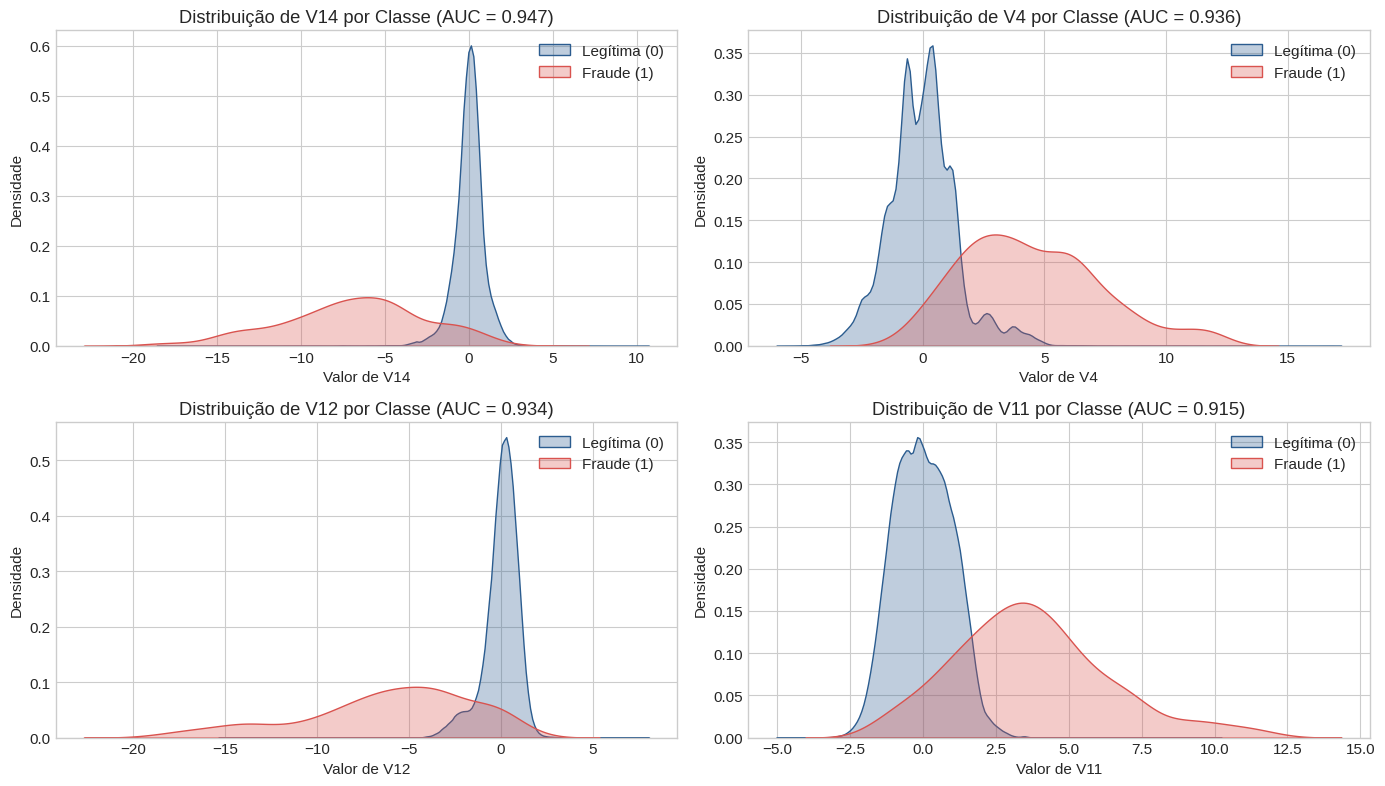

In [22]:
# Distribuição por classe dos atributos mais discriminatórios
# Critério documentado: os 4 atributos de maior ROC-AUC univariada (tabela acima)
principais_atributos = ranking.index[:4].tolist()
print(f"Atributos escolhidos (top 4 por AUC): {principais_atributos}")
print(f"Escolha da versão anterior (sem critério explícito): ['V17', 'V14', 'V12', 'V4']; "
      f"V17 é o 1º por |r| mas o {ranking.loc['V17', 'pos_AUC']}º por AUC")

fig, eixos = plt.subplots(2, 2, figsize=(14, 8))
eixos = eixos.flatten()

for i, atributo in enumerate(principais_atributos):
    sns.kdeplot(dados[dados['Class'] == 0][atributo], ax=eixos[i], label='Legítima (0)', fill=True, color=COR_LEGITIMA, alpha=0.3)
    sns.kdeplot(dados[dados['Class'] == 1][atributo], ax=eixos[i], label='Fraude (1)', fill=True, color=COR_FRAUDE, alpha=0.3)
    eixos[i].set_title(f"Distribuição de {atributo} por Classe (AUC = {ranking.loc[atributo, 'AUC']:.3f})")
    eixos[i].set_xlabel(f'Valor de {atributo}')
    eixos[i].set_ylabel('Densidade')
    eixos[i].legend()

plt.tight_layout()
plt.show()

**O que observamos:** Pelo critério documentado (top 4 por AUC), os atributos escolhidos são V14, V4, V12 e V11. A versão anterior usava V17, V14, V12 e V4, sem critério explícito (V17, V14 e V12 são os três primeiros por |r|, mas V4 é só o 9º): três se mantêm e V17 dá lugar a V11. Em todos, as legítimas formam um pico estreito perto de zero e as fraudes se espalham para um lado (valores negativos em V14 e V12, positivos em V4 e V11). A sobreposição perto de zero explica AUCs altas, mas abaixo de 1.

Maior |r| entre V's - todos os dados: 0.019
Maior |r| entre V's - só legítimas:   0.171
Maior |r| entre V's - só fraudes:     0.972
Correlação de Amount com V2, V7 e V20 (todos os dados): {'V2': -0.53, 'V7': 0.4, 'V20': 0.34}


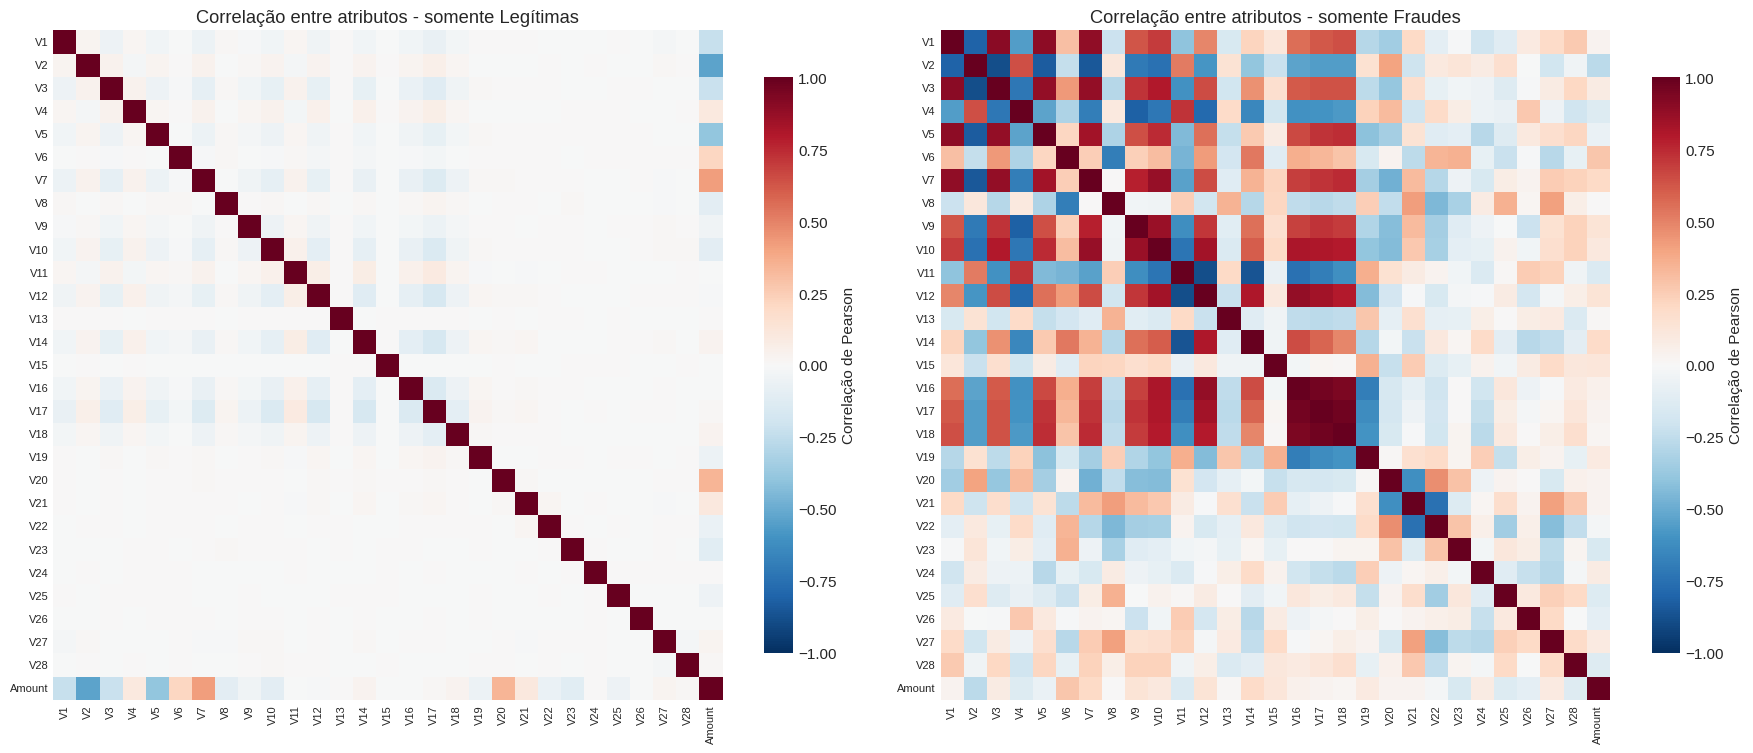

Pares de V's com |r| > 0,8: 25 nas fraudes x 0 nas legítimas (de 378 pares)


,atributo_1,atributo_2,r_fraudes,r_legitimas
312,V17,V18,0.972,-0.097
300,V16,V17,0.962,-0.147
301,V16,V18,0.945,-0.052
1,V1,V3,0.906,-0.051
3,V1,V5,0.894,-0.036
225,V11,V12,-0.891,0.065
5,V1,V7,0.889,-0.057
27,V2,V3,-0.883,0.039


In [23]:
# Correlação ENTRE os atributos, calculada separadamente dentro de cada classe
colunas_corr = COLUNAS_V + ['Amount']
corr_todos = dados[colunas_corr].corr()
corr_legitimas = dados.loc[dados['Class'] == 0, colunas_corr].corr()
corr_fraudes = dados.loc[dados['Class'] == 1, colunas_corr].corr()

def maior_correlacao_entre_vs(matriz):
    """Maior |r| entre duas V's diferentes (fora da diagonal)."""
    valores = matriz.loc[COLUNAS_V, COLUNAS_V].abs().to_numpy().copy()
    np.fill_diagonal(valores, 0)
    return valores.max()

print(f"Maior |r| entre V's - todos os dados: {maior_correlacao_entre_vs(corr_todos):.3f}")
print(f"Maior |r| entre V's - só legítimas:   {maior_correlacao_entre_vs(corr_legitimas):.3f}")
print(f"Maior |r| entre V's - só fraudes:     {maior_correlacao_entre_vs(corr_fraudes):.3f}")
print(f"Correlação de Amount com V2, V7 e V20 (todos os dados): {corr_todos.loc['Amount', ['V2', 'V7', 'V20']].round(2).to_dict()}")

fig, eixos = plt.subplots(1, 2, figsize=(18, 8))
for eixo, matriz, titulo in zip(eixos, [corr_legitimas, corr_fraudes], ['Legítimas', 'Fraudes']):
    sns.heatmap(matriz, ax=eixo, cmap='RdBu_r', vmin=-1, vmax=1, center=0, square=True,
                xticklabels=True, yticklabels=True, cbar_kws={'shrink': 0.75, 'label': 'Correlação de Pearson'})
    eixo.set_title(f'Correlação entre atributos - somente {titulo}')
    eixo.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

# Pares de V's mais correlacionados dentro das fraudes
linha_i, coluna_j = np.triu_indices(len(COLUNAS_V), k=1)
pares = pd.DataFrame({
    'atributo_1': [COLUNAS_V[i] for i in linha_i],
    'atributo_2': [COLUNAS_V[j] for j in coluna_j],
    'r_fraudes': corr_fraudes.loc[COLUNAS_V, COLUNAS_V].to_numpy()[linha_i, coluna_j],
    'r_legitimas': corr_legitimas.loc[COLUNAS_V, COLUNAS_V].to_numpy()[linha_i, coluna_j],
})
print(f"Pares de V's com |r| > 0,8: {(pares['r_fraudes'].abs() > 0.8).sum()} nas fraudes x "
      f"{(pares['r_legitimas'].abs() > 0.8).sum()} nas legítimas (de {len(pares)} pares)")
display(pares.loc[pares['r_fraudes'].abs().sort_values(ascending=False).index].head(8).round(3))

**O que observamos:** Nos dados completos as V's são praticamente não correlacionadas entre si (maior |r| = 0,019), como se espera de componentes PCA, e o mesmo vale dentro das legítimas (máximo de 0,171). **Dentro das fraudes, porém, elas são muito redundantes**: 25 pares têm |r| > 0,8 (nenhum nas legítimas), com máximo de 0,972 entre V17 e V18, e o bloco V16-V17-V18 funciona quase como uma única variável. Isso explica por que, nos testes preliminares, retirar V17, V14, V12 e V4 reduziu pouco a AP do XGBoost (de 0,848 para 0,818): as outras V's carregam quase a mesma informação. `Amount` é a exceção nos dados completos, com correlação de -0,53 com V2, 0,40 com V7 e 0,34 com V20.

## 6. Outliers: remover ou não?

Uma regra comum é marcar como *outlier* todo valor fora do intervalo `[Q1 - 1,5 x IQR, Q3 + 1,5 x IQR]`, em que IQR = Q3 - Q1.
Avaliamos o que essa regra faria com os atributos mais discriminatórios, com `Amount` e com a regra "outlier em qualquer V".

In [24]:
# Regra de outlier de 1,5 x IQR aplicada a uma coluna
def marcar_outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)

def resumo_outliers(marcado):
    return {'% das transações marcadas': 100 * marcado.mean(),
            '% das fraudes marcadas': 100 * marcado[eh_fraude].mean(),
            'taxa de fraude nos outliers (%)': 100 * dados.loc[marcado, 'Class'].mean(),
            'taxa de fraude no restante (%)': 100 * dados.loc[~marcado, 'Class'].mean()}

atributos_avaliados = ranking.index[:6].tolist() + ['V17', 'Amount']
tabela_outliers = pd.DataFrame({atributo: resumo_outliers(marcar_outliers_iqr(dados[atributo]))
                                for atributo in atributos_avaliados}).T

# Regra "outlier em qualquer uma das 28 V's"
outlier_em_qualquer_v = dados[COLUNAS_V].apply(marcar_outliers_iqr).any(axis=1)
tabela_outliers.loc['Qualquer V (V1-V28)'] = resumo_outliers(outlier_em_qualquer_v)
display(tabela_outliers.round(2))

,% das transações marcadas,% das fraudes marcadas,taxa de fraude nos outliers (%),taxa de fraude no restante (%)
V14,4.96,86.89,2.92,0.02
V4,3.91,63.42,2.70,0.06
V12,5.39,82.45,2.55,0.03
V11,0.26,58.35,37.55,0.07
V10,3.29,80.34,4.07,0.03
V3,1.17,61.95,8.86,0.06
V17,2.59,80.13,5.15,0.03
Amount,11.17,18.39,0.27,0.15
Qualquer V (V1-V28),45.14,96.83,0.36,0.01


**O que observamos:** A regra do IQR aplicada a qualquer uma das V's marcaria **45,1% das transações e 96,8% das fraudes**: remover esses pontos apagaria quase todo o sinal. Mesmo num único atributo, os "outliers" são justamente as fraudes: em V14, 4,96% das transações são marcadas, mas elas contêm 86,9% das fraudes (taxa de 2,92% contra 0,02% no restante); em V11, os 0,26% marcados têm taxa de fraude de 37,6%. Em `Amount`, os outliers (11,2% das transações) têm taxa de fraude só um pouco maior que o restante (0,27% contra 0,15%).

### Decisão: não remover outliers

Nas V's, os valores extremos **são o sinal de fraude**, não ruído: removê-los eliminaria justamente os casos que queremos detectar e deixaria o treino artificialmente diferente do uso real. As caudas pesadas são tratadas de outra forma: o LightGBM divide os dados por limiares e não é afetado pela magnitude dos valores extremos, e o SGD e a MLP recebem os atributos padronizados pelo `StandardScaler`. Nenhuma linha é removida além das duplicatas exatas.

## 7. Partição Estratificada (Salva em Arquivo)

### Etapas:
1. **Seleção de Atributos**: Descartamos a coluna `Time` original em segundos (substituída por `Horas_Dia`) e separamos o alvo `Class`. Os 30 atributos são `V1`-`V28`, `Amount` e `Horas_Dia` (`COLUNAS_ATRIBUTOS` em `src/preparo.py`).
2. **Divisão Estratificada**: Separação em **80% Treino** e **20% Teste** mantendo a mesma proporção de fraudes (`stratify`), com semente fixa (`random_state=42`), feita sobre os dados **sem duplicatas**.
3. **Partição salva**: Os índices de treino e teste são salvos em `resultados/split_indices.npz`. Os notebooks de modelagem leem esse arquivo com `carregar_particao()`, garantindo que os três modelos usem **exatamente as mesmas linhas**.
4. **Escalonamento fora deste notebook**: A versão anterior aplicava um `RobustScaler` aqui. Agora os dados são salvos **brutos** e cada modelo deve receber o seu pré-processamento dentro de um `Pipeline` na etapa de modelagem: por exemplo, `StandardScaler` + `SGDClassifier` e `StandardScaler` + `MLPClassifier` (modelos sensíveis à escala); o LightGBM pode usar os atributos brutos (árvores não dependem de escala). Como o `Pipeline` é ajustado dentro de cada fold da validação cruzada, o escalonamento nunca "vê" os dados de validação ou de teste.

In [25]:
# 1. Divisão estratificada (80% treino, 20% teste) com semente fixa, sobre os dados SEM duplicatas
idx_treino, idx_teste = dividir_treino_teste(dados)   # test_size=0.20, random_state=42, stratify=Class

# 2. Os índices são salvos em arquivo para os próximos notebooks
salvar_split(idx_treino, idx_teste)
print(f"Partição salva em: {CAMINHO_SPLIT.relative_to(RAIZ_PROJETO)}")

# 3. Leitura de volta, como farão os notebooks de modelagem (atributos brutos, sem escalonamento)
treino_x, teste_x, treino_y, teste_y = carregar_particao(dados)

# 4. Verificação final da integridade e proporções
print("\n=== Verificação da Divisão Estratificada ===")
print(f"Formato Treino X: {treino_x.shape[0]:,} linhas, {treino_x.shape[1]} colunas")
print(f"Formato Teste X:  {teste_x.shape[0]:,} linhas, {teste_x.shape[1]} colunas")

print(f"\nFraudes no Treino: {treino_y.sum():,} de {len(treino_y):,} ({treino_y.mean()*100:.3f}%)")
print(f"Fraudes no Teste:  {teste_y.sum():,} de {len(teste_y):,} ({teste_y.mean()*100:.3f}%)")

Partição salva em: resultados/split_indices.npz

=== Verificação da Divisão Estratificada ===
Formato Treino X: 226,980 linhas, 30 colunas
Formato Teste X:  56,746 linhas, 30 colunas

Fraudes no Treino: 378 de 226,980 (0.167%)
Fraudes no Teste:  95 de 56,746 (0.167%)


In [26]:
# Verificações de vazamento entre treino e teste
# (a) Cópias exatas: nenhuma linha do teste pode ter uma gêmea no treino
assinatura_nova = pd.util.hash_pandas_object(dados[COLUNAS_ORIGINAIS], index=False)
gemeos_no_treino = assinatura_nova.loc[idx_teste].isin(assinatura_nova.loc[idx_treino].to_numpy()).sum()
print(f"Linhas do teste com cópia exata no treino: {gemeos_no_treino} (na divisão antiga: {tem_gemeo_no_treino.sum()})")

# (b) Rajadas: fraudes do teste que têm uma fraude do TREINO a até 60 s (a divisão aleatória separa rajadas)
tempos_fraude_treino = dados.loc[idx_treino].query('Class == 1')['Time'].to_numpy()
tempos_fraude_teste = dados.loc[idx_teste].query('Class == 1')['Time'].to_numpy()
distancia_minima = np.array([np.abs(tempos_fraude_treino - tempo).min() for tempo in tempos_fraude_teste])
print(f"Fraudes do teste com uma fraude do treino a até 60 s: {(distancia_minima <= 60).sum()} de {len(tempos_fraude_teste)}")

Linhas do teste com cópia exata no treino: 0 (na divisão antiga: 344)
Fraudes do teste com uma fraude do treino a até 60 s: 39 de 95


**O que observamos:** A partição tem 226.980 transações de treino (378 fraudes) e 56.746 de teste (95 fraudes), ambas com 0,167% de fraudes, e **nenhuma linha do teste tem cópia exata no treino** (eram 344 na divisão antiga). As rajadas, porém, atravessam a partição: 39 das 95 fraudes do teste têm uma fraude do treino a até 60 s. Isso não é um erro da divisão aleatória, mas é o motivo para fazer também, na modelagem, a verificação com a partição temporal (`particao_temporal()`). Com só 95 fraudes no teste, a incerteza da AP é grande (nos testes preliminares da revisão, o intervalo bootstrap de 95% teve largura da ordem de 0,15 a 0,21): o teste deve ser usado uma única vez e sempre com intervalo de confiança.

## 8. Síntese dos Resultados e Recomendações para a Modelagem

1. **Dados limpos**: não há valores ausentes. As 1.081 duplicatas exatas (19 delas cópias de fraudes) foram removidas antes da divisão; restam **283.726 transações e 473 fraudes**, uma prevalência de **0,167%** (0,173% no arquivo original).
2. **Acurácia é enganosa**: responder sempre "legítima" dá 99,833% de acurácia sem detectar nenhuma fraude. A referência da AP é a prevalência (0,00167).
3. **Tempo**: supondo que `Time = 0` é meia-noite, a madrugada (0h-6h) tem 26,2% das fraudes com 9,8% das transações, e a taxa chega a 1,45% às 2h (quase 9 vezes a global). A taxa foi maior no dia 1 (0,189% x 0,144%), mas por causa dos picos das 7h e 11h, que vêm quase só desse dia (sem eles, 0,156% x 0,150%). As fraudes chegam em rajadas (52,0% têm outra fraude a até 60 s, contra 33,6% ao acaso); contando rajadas em vez de fraudes, o efeito da madrugada se mantém e a diferença entre os dias deixa de ser significativa.
4. **Valor (`Amount`)**: a taxa de fraude tem forma de U (1,38% no valor zero, mínimo de 0,054% entre US$ 10 e 25, 0,40% entre US$ 500 e 1.000); sozinho, `Amount` é um separador monotônico fraco (AUC 0,556), mas a forma de U pode ser aproveitada por modelos não lineares.
5. **V1-V28**: pela ROC-AUC univariada, os atributos mais discriminatórios são V14, V4, V12 e V11 (AUC de 0,915 a 0,947); a correlação de Pearson subestima alguns deles (V4 é só o 9º por |r|). Dentro das fraudes as V's são muito redundantes (até r = 0,97). Essas estatísticas são descritivas: **os 30 atributos vão todos para os modelos**.
6. **Outliers mantidos**: nas V's eles são o próprio sinal de fraude (a regra do IQR em qualquer V removeria 96,8% das fraudes).
7. **Partição salva**: 80/20 estratificada com `random_state=42` sobre os dados sem duplicatas, com treino de 226.980 transações (378 fraudes) e teste de 56.746 (95 fraudes), em `resultados/split_indices.npz`. Nenhum escalonamento é aplicado aqui: ele fica dentro do `Pipeline` de cada modelo.

### Recomendações para as próximas etapas
- **Modelos comparados**: `SGDClassifier` com `loss='log_loss'` (ranqueado pela `decision_function`, porque o seu `predict_proba` satura em 1,0) e rede neural `MLPClassifier`, ambos com `StandardScaler` no `Pipeline`; e **LightGBM** sobre os atributos brutos, com `min_child_weight` e `reg_lambda` ajustados (com os parâmetros padrão ele diverge neste dataset).
- **Métrica principal**: Average Precision (`average_precision_score`, a área sob a curva precisão-recall calculada em degraus; não usar `auc(recall, precisao)`, que interpola e favorece modelos fracos). ROC-AUC como métrica secundária: fica alta para todos e quase não diferencia os modelos.
- **Limiar**: escolhido nas previsões *out-of-fold* do treino (máximo F2 ou menor custo), **nunca 0,5 fixo**.
- **Comparação estatística**: validação cruzada estratificada repetida (5 folds x 3 repetições) com teste t corrigido de Nadeau-Bengio e correção de Holm; no teste, intervalo bootstrap da AP e bootstrap pareado da diferença entre modelos.
- **Conjunto de teste usado uma única vez**, ao final. A partição temporal (`particao_temporal()` em `src/preparo.py`, recomendada por causa das rajadas) serve como verificação de robustez.

### Como usar os dados nas próximas etapas
Os notebooks de modelagem carregam a mesma partição salva por este notebook, já sem duplicatas e sem escalonamento:

```python
from src.preparo import carregar_particao

X_treino, X_teste, y_treino, y_teste = carregar_particao()
# treino: 226.980 transações (378 fraudes); teste: 56.746 (95 fraudes)
# 30 atributos: V1-V28, Amount e Horas_Dia
```